--- Model Parameters ---
Weight 1 (w1): 0.3344
Weight 2 (w2): 0.2122
Bias (b): -1.5178

--- Classification Metrics ---
   Metric  Value
 Accuracy 0.9350
Precision 0.8850
   Recall 1.0000
 F1 Score 0.9390
 Log Loss 0.3482

--- Confusion Matrix Values ---
True Positive  (TP): 200
True Negative  (TN): 174
False Positive (FP): 26
False Negative (FN): 0


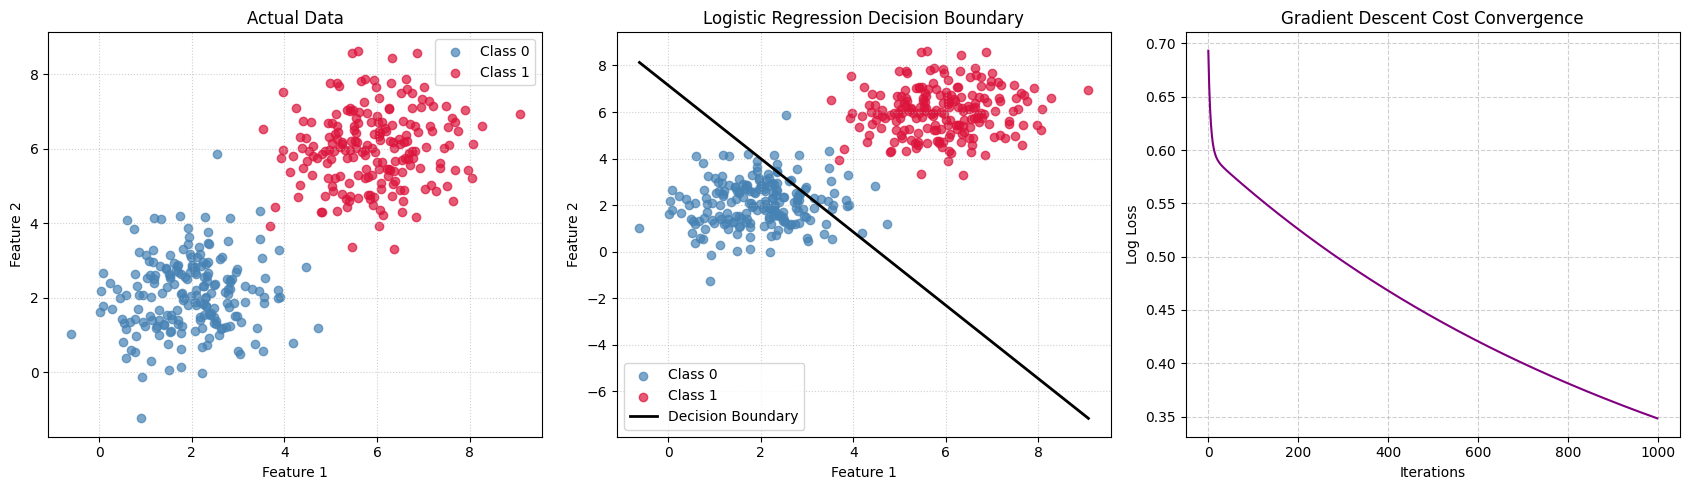

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)

n = 200

x1 = np.random.normal(2, 1, n)
x2 = np.random.normal(2, 1, n)

x3 = np.random.normal(6, 1, n)
x4 = np.random.normal(6, 1, n)

x = np.vstack([
    np.column_stack((x1, x2)),
    np.column_stack((x3, x4))
])

y = np.hstack([
    np.zeros(n),
    np.ones(n)
])

idx = np.random.permutation(2 * n)

x = x[idx]
y = y[idx]

df = pd.DataFrame({
    "x1": x[:, 0],
    "x2": x[:, 1],
    "Target": y
})


class LR:

    def __init__(self, lr=0.01, it=1000):
        self.lr = lr
        self.it = it
        self.w = None
        self.b = None
        self.cost = []

    def sigmoid(self, z):

        z = np.clip(z, -500, 500)

        return 1 / (1 + np.exp(-z))

    def fit(self, x, y):

        m, nf = x.shape

        self.w = np.zeros(nf)
        self.b = 0.0
        self.cost = []

        for _ in range(self.it):

            z = np.dot(x, self.w) + self.b

            yp = self.sigmoid(z)

            eps = 1e-15

            c = -(1 / m) * np.sum(
                y * np.log(yp + eps) +
                (1 - y) * np.log(1 - yp + eps)
            )

            self.cost.append(c)

            dw = (1 / m) * np.dot(x.T, (yp - y))
            db = (1 / m) * np.sum(yp - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_prob(self, x):

        z = np.dot(x, self.w) + self.b

        return self.sigmoid(z)

    def predict(self, x, th=0.5):

        yp = self.predict_prob(x)

        return (yp >= th).astype(int)

    def accuracy(self, yt, yp):

        return np.mean(yt == yp)

    def precision(self, yt, yp):

        tp = np.sum((yt == 1) & (yp == 1))
        fp = np.sum((yt == 0) & (yp == 1))

        return tp / (tp + fp) if (tp + fp) != 0 else 0

    def recall(self, yt, yp):

        tp = np.sum((yt == 1) & (yp == 1))
        fn = np.sum((yt == 1) & (yp == 0))

        return tp / (tp + fn) if (tp + fn) != 0 else 0

    def f1(self, yt, yp):

        p = self.precision(yt, yp)
        r = self.recall(yt, yp)

        return 2 * p * r / (p + r) if (p + r) != 0 else 0

    def log_loss(self, yt, yp):

        eps = 1e-15

        yp = np.clip(yp, eps, 1 - eps)

        return -np.mean(
            yt * np.log(yp) +
            (1 - yt) * np.log(1 - yp)
        )

    def confusion(self, yt, yp):

        tp = np.sum((yt == 1) & (yp == 1))
        tn = np.sum((yt == 0) & (yp == 0))
        fp = np.sum((yt == 0) & (yp == 1))
        fn = np.sum((yt == 1) & (yp == 0))

        return tp, tn, fp, fn


x = df[["x1", "x2"]].values
y = df["Target"].values

model = LR(lr=0.01, it=1000)

model.fit(x, y)

prob = model.predict_prob(x)

yp = model.predict(x)


acc = model.accuracy(y, yp)
pre = model.precision(y, yp)
rec = model.recall(y, yp)
f1 = model.f1(y, yp)
loss = model.log_loss(y, prob)

tp, tn, fp, fn = model.confusion(y, yp)


met = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Log Loss"
    ],

    "Value": [
        f"{acc:.4f}",
        f"{pre:.4f}",
        f"{rec:.4f}",
        f"{f1:.4f}",
        f"{loss:.4f}"
    ]
})


print("--- Model Parameters ---")

print(f"Weight 1 (w1): {model.w[0]:.4f}")
print(f"Weight 2 (w2): {model.w[1]:.4f}")
print(f"Bias (b): {model.b:.4f}\n")


print("--- Classification Metrics ---")

print(met.to_string(index=False))


print("\n--- Confusion Matrix Values ---")

print(f"True Positive  (TP): {tp}")
print(f"True Negative  (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")


fig, ax = plt.subplots(1, 3, figsize=(17, 5))


# Actual classes

ax[0].scatter(
    x[y == 0, 0],
    x[y == 0, 1],
    color="steelblue",
    alpha=0.7,
    label="Class 0"
)

ax[0].scatter(
    x[y == 1, 0],
    x[y == 1, 1],
    color="crimson",
    alpha=0.7,
    label="Class 1"
)

ax[0].set_title("Actual Data")
ax[0].set_xlabel("Feature 1")
ax[0].set_ylabel("Feature 2")
ax[0].legend()
ax[0].grid(True, linestyle=":", alpha=0.6)


# Decision boundary

ax[1].scatter(
    x[y == 0, 0],
    x[y == 0, 1],
    color="steelblue",
    alpha=0.7,
    label="Class 0"
)

ax[1].scatter(
    x[y == 1, 0],
    x[y == 1, 1],
    color="crimson",
    alpha=0.7,
    label="Class 1"
)

xv = np.linspace(
    x[:, 0].min(),
    x[:, 0].max(),
    100
)

yv = -(model.w[0] * xv + model.b) / model.w[1]

ax[1].plot(
    xv,
    yv,
    color="black",
    linewidth=2,
    label="Decision Boundary"
)

ax[1].set_title("Logistic Regression Decision Boundary")
ax[1].set_xlabel("Feature 1")
ax[1].set_ylabel("Feature 2")
ax[1].legend()
ax[1].grid(True, linestyle=":", alpha=0.6)


# Cost convergence

ax[2].plot(
    range(len(model.cost)),
    model.cost,
    color="purple"
)

ax[2].set_xlabel("Iterations")
ax[2].set_ylabel("Log Loss")
ax[2].set_title("Gradient Descent Cost Convergence")
ax[2].grid(True, linestyle="--", alpha=0.6)


plt.tight_layout()
plt.show()